In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

X = np.load("/content/drive/MyDrive/Colab Notebooks/X_patches.npy")
y = np.load("/content/drive/MyDrive/Colab Notebooks/y_labels.npy")

LABEL_MAP = {0: "Normal", 1: "Inner Race", 2: "Ball", 3: "Outer Race_Center",
             4: "Outer Race_Oppo", 5: "Outer Race_Ortho"}

N_CLASSES = len(LABEL_MAP)

print(f"X shape:{X.shape}")
print(f"y shape:{y.shape}")

X shape:(480, 65, 185)
y shape:(480,)


In [24]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

total = len(y)
class_weight = {
    i: total / (N_CLASSES * int(np.sum(y == i)))
    for i in range(N_CLASSES)
}
for i, weight in class_weight.items():
    bar = "█" * int(weight * 10)
    print(f"  {LABEL_MAP[i]:12s}: weight = {weight:.3f}  {bar}")

# Add channel dimension for CNN: (96, 65, 185) → (96, 65, 185, 1)
X_cnn = X[..., np.newaxis]

# Normalize to [0, 1]
X_min = X_train.min()
X_max = X_train.max()
X_train = (X_train - X_min) / (X_max - X_min)
X_test  = (X_test - X_min) / (X_max - X_min)
print(f"\nX_cnn shape: {X_cnn.shape}")
print(f"Value range: {X_cnn.min():.3f} – {X_cnn.max():.3f}")

# Train/Test split – 80/20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

TensorFlow version: 2.19.0
  Normal      : weight = 1.000  ██████████
  Inner Race  : weight = 1.000  ██████████
  Ball        : weight = 1.000  ██████████
  Outer Race_Center: weight = 1.000  ██████████
  Outer Race_Oppo: weight = 1.000  ██████████
  Outer Race_Ortho: weight = 1.000  ██████████

X_cnn shape: (480, 65, 185, 1)
Value range: -126.130 – -4.838

Train: 384 samples
Test:  96 samples


In [25]:
from tensorflow.keras import layers, models

def build_cnn(input_shape, n_classes):
  """
  Small CNN for spectrogram patch classification.
  Input: (height, width, channels) = (65, 185, 1)
  Output: probability distribution over m_classes
  """
  model = models.Sequential([
      #Block 1 - learn low level patterns (edges, ridges)
      layers.Conv2D(8, (3, 3), activation="relu",
                    input_shape=input_shape,
                    kernel_regularizer=tf.keras.regularizers.l2(0.01)),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2, 2)),
      layers.Dropout(0.3),

      #Block 2 - learn higher-level patterns
      layers.Conv2D(16, (3, 3), activation="relu"),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2, 2)),
      layers.Dropout(0.3),

      #Block 3 - learn abstract features - reducing parameters from 540k to 50k
      #layers.Conv2D(64, (3, 3), activation="relu"),
      #layers.BatchNormalization(),
      #layers.MaxPooling2D((2, 2)),

      #Classifier head
      layers.Flatten(),
      layers.Dense(32, activation="relu",
                   kernel_regularizer=tf.keras.regularizers.l2(0.01)),
      layers.Dropout(0.4),
      layers.Dense(n_classes, activation="softmax")
  ])
  return model

  input_shape = X_train.shape[1:]
  model = build_cnn(input_shape, N_CLASSES)
  model.summary()

In [26]:
# Debug Cell
input_shape = X_train.shape[1:]
model = build_cnn(input_shape, N_CLASSES)
model.summary()

print(input_shape)
print(N_CLASSES)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 63, 183, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 63, 183, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 91, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 31, 91, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 89, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 29, 89, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 44, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 44, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       315,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,966 (1.21 MB)

 Trainable params: 316,918 (1.21 MB)

 Non-trainable params: 48 (192.00 B)

(65, 185, 1)
6


In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10, # stop if no improvement for 10 epochs
    restore_best_weights=True, # revert to best weights automatically
    mode='max',
)

model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )

history = model.fit(
      X_train, y_train,
      epochs=100,
      batch_size=32,
      validation_data=(X_test, y_test),
      class_weight=class_weight,
      callbacks=[early_stop],
      verbose=1
  )

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.4974 - loss: 2.1119 - val_accuracy: 0.3333 - val_loss: 12.0977
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 0.7109 - loss: 1.3728 - val_accuracy: 0.3333 - val_loss: 7.6500
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.7708 - loss: 1.1603 - val_accuracy: 0.3333 - val_loss: 10.0856
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.7969 - loss: 1.0704 - val_accuracy: 0.3333 - val_loss: 8.7591
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.8672 - loss: 0.8968 - val_accuracy: 0.3333 - val_loss: 8.9374
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.8932 - loss: 0.8330 - val_accuracy: 0.3333 - val_loss: 9.8418
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.9193 - loss: 0.7447 - val_accuracy: 0.3333 - val_loss: 5.7736
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.9089 - loss: 0.7078 - val_ac

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
                   precision    recall  f1-score   support

           Normal       1.00      1.00      1.00        16
       Inner Race       1.00      1.00      1.00        16
             Ball       1.00      1.00      1.00        16
Outer Race_Center       1.00      1.00      1.00        16
  Outer Race_Oppo       1.00      1.00      1.00        16
 Outer Race_Ortho       1.00      1.00      1.00        16

         accuracy                           1.00        96
        macro avg       1.00      1.00      1.00        96
     weighted avg       1.00      1.00      1.00        96



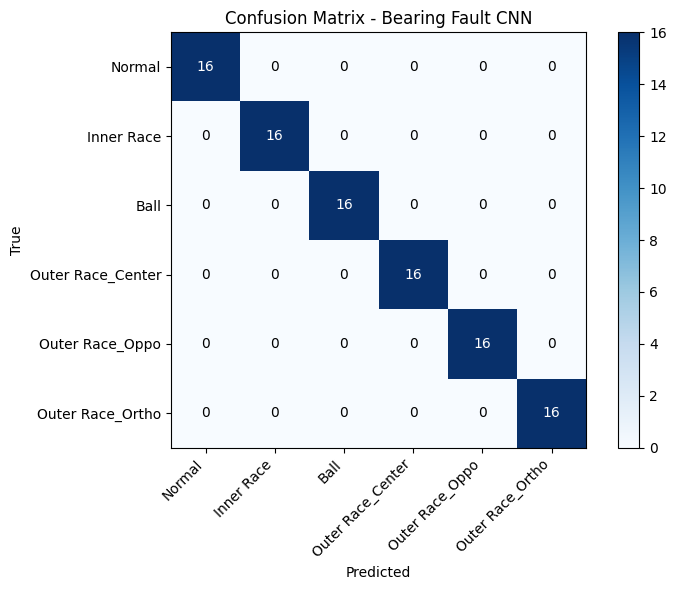

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred,
                            target_names=list(LABEL_MAP.values())
))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(LABEL_MAP)))
ax.set_yticks(range(len(LABEL_MAP)))
ax.set_xticklabels(list(LABEL_MAP.values()), rotation=45, ha="right")
ax.set_yticklabels(list(LABEL_MAP.values()))

for i in range(len(LABEL_MAP)):
  for j in range(len(LABEL_MAP)):
    ax.text(j, i, cm[i, j], ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black")

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Bearing Fault CNN")
plt.colorbar(im)
plt.tight_layout()
plt.show()

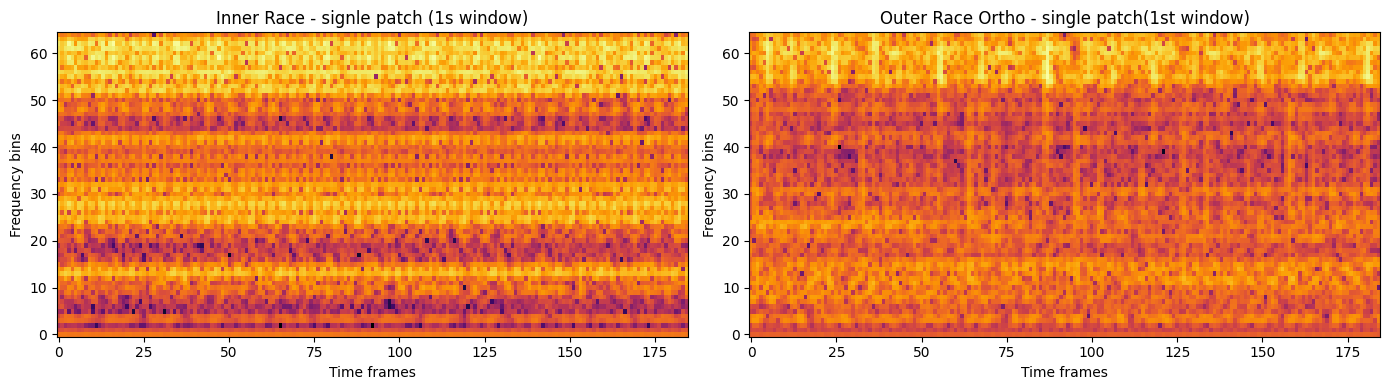

In [15]:
# Inner Race gets always confused with Outer Race Orthogonal
# dive deeper in what the CNN sees

idx_inner = np.where(y_test == 1)[0][0]
idx_ortho = np.where(y_test == 5)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(X_test[idx_inner, :, :, 0],
               aspect="auto", origin="lower", cmap="inferno")
axes[0].set_title("Inner Race - signle patch (1s window)")
axes[0].set_xlabel("Time frames")
axes[0].set_ylabel("Frequency bins")

axes[1].imshow(X_test[idx_ortho, :, :, 0],
               aspect="auto", origin="lower", cmap="inferno")
axes[1].set_title("Outer Race Ortho - single patch(1st window)")
axes[1].set_xlabel("Time frames")
axes[1].set_ylabel("Frequency bins")

plt.tight_layout()
plt.show()

In [17]:
# Further investigation, whether the splits are nice due to heavy confusion from Inner Race to Outer Race Ortho

print("Train distribution:")
for i, name in LABEL_MAP.items():
  count = int(np.sum(y_train == i))
  print(f"  {name:22s}: {count}")

print(f"\nTest distribution:")
for i, name in LABEL_MAP.items():
  count = int(np.sum(y_test == i))
  print(f"  {name:22s}: {count}")

Train distribution:
  Normal                : 64
  Inner Race            : 64
  Ball                  : 64
  Outer Race_Center     : 64
  Outer Race_Oppo       : 64
  Outer Race_Ortho      : 64

Test distribution:
  Normal                : 16
  Inner Race            : 16
  Ball                  : 16
  Outer Race_Center     : 16
  Outer Race_Oppo       : 16
  Outer Race_Ortho      : 16


In [30]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("bearing_fault_model.tflite", "wb") as f:
  f.write(tflite_model)

print(f"Model size: {len(tflite_model) / 1024:.1f} KB")

Saved artifact at '/tmp/tmpx1xgw6za'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 65, 185, 1), dtype=tf.float32, name='keras_tensor_26')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137362967074128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967077392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967071632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967073360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967076432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967082192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967083344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967073168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137363073786384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137363073783888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137362967076

In [31]:
# Load and test the TFLite model to verify it works
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input shape:  {input_details[0]['shape']}")
print(f"Input dtype:  {input_details[0]['dtype']}")
print(f"Output shape: {output_details[0]['shape']}")

# Run inference on one test sample
sample = X_test[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], sample)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

predicted_class = np.argmax(output)
true_class      = y_test[0]

print(f"\nTrue label:      {LABEL_MAP[true_class]}")
print(f"Predicted label: {LABEL_MAP[predicted_class]}")
print(f"Confidence:      {output[0][predicted_class]*100:.1f}%")

Input shape:  [  1  65 185   1]
Input dtype:  <class 'numpy.float32'>
Output shape: [1 6]

True label:      Outer Race_Oppo
Predicted label: Outer Race_Oppo
Confidence:      100.0%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
